### **1. Notebook Set-up**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/toffickmohammed/gait-imu-grf-data/gait_data/pelvis_bilateral_grf.csv
/kaggle/input/datasets/toffickmohammed/gait-imu-grf-data/gait_data/fusion_bilateral_grf.csv
/kaggle/input/datasets/toffickmohammed/gait-imu-grf-data/gait_data/bilateral_shanks_bilateral_grf.csv


### **Downloading Data from Google Drive Into Kaggle**

In [2]:
# !pip install -q --upgrade gdown

# import gdown

# folder_url = "https://drive.google.com/drive/folders/1Yfu1T7ykYOiKzu4PfINaBimXE8i20aKd?usp=drive_link"

# save_path = "/kaggle/working/gait_data"

# downloaded_files = gdown.download_folder(
#     url=folder_url,
#     output=save_path,
#     quiet=False,
#     use_cookies=False
# )

# print("\nDownloaded files:", len(downloaded_files))
# print("Saved inside:", save_path)

In [3]:
# from pathlib import Path

# DATA_FOLDER = Path("/kaggle/working/gait_data")

# files = [file for file in DATA_FOLDER.rglob("*") if file.is_file()]

# print("Files found:", len(files))

# for file in files[:20]:
#     print(file)

### Intepretation
- Data was downloaded from Google drive and after saved as a private Dataset which makes it possible for it to be used in multiple notebooks.
- Lavikanean and grouvel datasets preprocessed and aggregated to form 3 separate datasets - Pevis configuration (600 IMU channels - 300 Accelerometer channels and 300 gyroscope channels) , Bilateral shanks(1200 IMU channels - 300 Accelerometer channels and 300 gyroscope channels each at the left and right shanks), Fusion configuration (basically combination of IMU channels from pelvis and Bilateral shanks (1800 IMU channels)

### **Standard LSTM**

### **2.Data Preparation**

## **2.1 Load and Inspect the Dataset**

In [4]:
from pathlib import Path
import pandas as pd

# Find the pelvis dataset
DATA_PATH = next(
    Path("/kaggle/input").rglob("pelvis_bilateral_grf.csv")
)

# Load the data
df = pd.read_csv(DATA_PATH)

# Inspect the data
print("File:", DATA_PATH)
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Data types:\n", df.dtypes.value_counts())
print("First 10 columns:", df.columns[:10].tolist())
print("Last 10 columns:", df.columns[-10:].tolist())

df.head()

File: /kaggle/input/datasets/toffickmohammed/gait-imu-grf-data/gait_data/pelvis_bilateral_grf.csv
Shape: (2893, 1204)
Missing values: 0
Data types:
 float64    1200
object        4
Name: count, dtype: int64
First 10 columns: ['Dataset', 'pid', 'trial', 'side', 'X_Pelvis_Acc_X_t000', 'X_Pelvis_Acc_Y_t000', 'X_Pelvis_Acc_Z_t000', 'X_Pelvis_Gyr_X_t000', 'X_Pelvis_Gyr_Y_t000', 'X_Pelvis_Gyr_Z_t000']
Last 10 columns: ['Y_Left_Fz_t098', 'Y_Right_Fx_t098', 'Y_Right_Fy_t098', 'Y_Right_Fz_t098', 'Y_Left_Fx_t099', 'Y_Left_Fy_t099', 'Y_Left_Fz_t099', 'Y_Right_Fx_t099', 'Y_Right_Fy_t099', 'Y_Right_Fz_t099']


/tmp/ipykernel_24/1119539093.py:10: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,Dataset,pid,trial,side,X_Pelvis_Acc_X_t000,X_Pelvis_Acc_Y_t000,X_Pelvis_Acc_Z_t000,X_Pelvis_Gyr_X_t000,X_Pelvis_Gyr_Y_t000,X_Pelvis_Gyr_Z_t000,...,Y_Left_Fz_t098,Y_Right_Fx_t098,Y_Right_Fy_t098,Y_Right_Fz_t098,Y_Left_Fx_t099,Y_Left_Fy_t099,Y_Left_Fz_t099,Y_Right_Fx_t099,Y_Right_Fy_t099,Y_Right_Fz_t099
0,Lavikainen,1,l_comf_01,Left,13.867336,-3.664119,-0.829981,-0.695395,0.115051,-0.055167,...,-46.252432,125.339664,-2.636805e+01,-759.716188,-12.366300,3.991289,-22.852904,125.958768,-2.924069e+01,-776.039582
1,Lavikainen,1,l_comf_01,Left,14.676754,-3.466618,-1.343591,-0.597411,-0.105410,0.163698,...,-57.641030,0.000011,7.639545e-08,0.000032,-15.625878,2.692979,-32.049513,0.000009,2.634933e-08,0.000025
2,Lavikainen,1,l_comf_01,Right,15.121733,0.820053,0.366695,0.719949,-0.030074,-0.170578,...,-740.348254,-24.707767,2.438968e-01,-59.283753,126.591714,-19.729988,-760.276092,-15.937856,3.154267e-01,-33.573989
3,Lavikainen,1,l_comf_02,Left,13.539703,-2.983842,-1.243961,-0.619939,0.215535,-0.001469,...,-50.695739,130.817684,-2.404386e+01,-760.649713,-12.636133,2.991458,-27.128543,132.288283,-2.741028e+01,-779.498250
4,Lavikainen,1,l_comf_02,Left,13.779099,-3.506871,-1.584863,-0.433770,0.233054,0.128595,...,-78.433995,0.000006,-3.517099e-07,0.000018,-20.359845,3.749952,-48.679565,0.000005,-3.129962e-07,0.000012


### **2.2 Identify metadata, IMU, and GRF columns**

In [5]:
# Metadata columns
metadata_cols = ["Dataset", "pid", "trial", "side"]

# Signal columns
imu_cols = [col for col in df.columns if col.startswith("X_")]
grf_cols = [col for col in df.columns if col.startswith("Y_")]

print("Metadata columns:", metadata_cols)
print("IMU columns:", len(imu_cols))
print("GRF columns:", len(grf_cols))

print("\nFirst 6 IMU columns:")
print(imu_cols[:6])

print("\nFirst 6 GRF columns:")
print(grf_cols[:6])

print("\nLast 6 GRF columns:")
print(grf_cols[-6:])

Metadata columns: ['Dataset', 'pid', 'trial', 'side']
IMU columns: 600
GRF columns: 600

First 6 IMU columns:
['X_Pelvis_Acc_X_t000', 'X_Pelvis_Acc_Y_t000', 'X_Pelvis_Acc_Z_t000', 'X_Pelvis_Gyr_X_t000', 'X_Pelvis_Gyr_Y_t000', 'X_Pelvis_Gyr_Z_t000']

First 6 GRF columns:
['Y_Left_Fx_t000', 'Y_Left_Fy_t000', 'Y_Left_Fz_t000', 'Y_Right_Fx_t000', 'Y_Right_Fy_t000', 'Y_Right_Fz_t000']

Last 6 GRF columns:
['Y_Left_Fx_t099', 'Y_Left_Fy_t099', 'Y_Left_Fz_t099', 'Y_Right_Fx_t099', 'Y_Right_Fy_t099', 'Y_Right_Fz_t099']


### **2.3 Check Data Quality**

In [6]:
# Check data quality
signal_data = df[imu_cols + grf_cols]

print("Missing values:", signal_data.isna().sum().sum())
print("Infinite values:", np.isinf(signal_data.to_numpy()).sum())
print("Duplicate rows:", df.duplicated().sum())
print("Constant signal columns:", (signal_data.nunique() <= 1).sum())

Missing values: 0
Infinite values: 0
Duplicate rows: 0
Constant signal columns: 0


### **2.4 Reshape X and Y**

In [7]:
# Convert flat columns into LSTM arrays
X = df[imu_cols].to_numpy().reshape(-1, 100, 6)
Y = df[grf_cols].to_numpy().reshape(-1, 100, 6)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (2893, 100, 6)
Y shape: (2893, 100, 6)


## **2.5 Create Participant Groups**

In [8]:
# Keep metadata
metadata = df[metadata_cols].copy()

# Create a unique participant ID across datasets
metadata["subject_id"] = (
    metadata["Dataset"].astype(str)
    + "_"
    + metadata["pid"].astype(str)
)

print("Total samples:", len(metadata))
print("Total participants:", metadata["subject_id"].nunique())

print("\nParticipants per dataset:")
print(metadata.groupby("Dataset")["subject_id"].nunique())

print("\nSamples per dataset:")
print(metadata["Dataset"].value_counts())

Total samples: 2893
Total participants: 58

Participants per dataset:
Dataset
Grouvel       10
Lavikainen    48
Name: subject_id, dtype: int64

Samples per dataset:
Dataset
Lavikainen    2800
Grouvel         93
Name: count, dtype: int64


### **2.6 Check Samples per Participant**

In [9]:
# Samples available for each participant
samples_per_subject = metadata["subject_id"].value_counts().sort_index()

print(samples_per_subject)
print("\nMinimum samples:", samples_per_subject.min())
print("Maximum samples:", samples_per_subject.max())

subject_id
Grouvel_P01       8
Grouvel_P02      10
Grouvel_P03       7
Grouvel_P04       7
Grouvel_P05      10
Grouvel_P06      12
Grouvel_P07      11
Grouvel_P08       8
Grouvel_P09      12
Grouvel_P10       8
Lavikainen_1     54
Lavikainen_10    60
Lavikainen_12    42
Lavikainen_13    54
Lavikainen_15    57
Lavikainen_16    48
Lavikainen_17    56
Lavikainen_18    54
Lavikainen_19    60
Lavikainen_2     69
Lavikainen_20    66
Lavikainen_21    54
Lavikainen_22    43
Lavikainen_23    45
Lavikainen_24    57
Lavikainen_25    74
Lavikainen_26    60
Lavikainen_27    60
Lavikainen_28    60
Lavikainen_29    60
Lavikainen_3     54
Lavikainen_30    57
Lavikainen_31    57
Lavikainen_32    66
Lavikainen_33    57
Lavikainen_34    54
Lavikainen_35    57
Lavikainen_36    60
Lavikainen_37    61
Lavikainen_38    57
Lavikainen_39    63
Lavikainen_4     60
Lavikainen_40    45
Lavikainen_41    60
Lavikainen_42    51
Lavikainen_43    63
Lavikainen_44    62
Lavikainen_45    62
Lavikainen_46    60
Lavikaine

## **2.7 Verify participant coverage**

In [10]:
## Step 7 — Verify Participant Coverage

# Expected Lavikainen participant IDs
expected_lav = set(map(str, range(1, 52)))

# Participant IDs in the current dataset
current_lav = set(
    metadata.loc[
        metadata["Dataset"] == "Lavikainen",
        "pid"
    ].astype(str)
)

print("Missing Lavikainen participants:",
      sorted(expected_lav - current_lav, key=int))

print("\nGrouvel samples:",
      (metadata["Dataset"] == "Grouvel").sum())

print("Lavikainen samples:",
      (metadata["Dataset"] == "Lavikainen").sum())

Missing Lavikainen participants: ['11', '14', '49']

Grouvel samples: 93
Lavikainen samples: 2800


### **Sample coverage note**

The final Grouvel dataset contains 93 stance samples. One of the 94 detected stance samples was excluded because its stance duration was below the minimum accepted threshold.

The final dataset contains 58 participants and 2,893 stance samples. Lavikainen participants 11, 14, and 49 were excluded because they had no IMU data. One Grouvel stance sample was excluded because its duration was below the minimum accepted threshold.

## **3. Experimental Design**

## **3.1 Define LOSO Cross-Validation**

In [11]:
from sklearn.model_selection import LeaveOneGroupOut

# Participant groups
groups = metadata["subject_id"].to_numpy()

# Define LOSO
loso = LeaveOneGroupOut()
folds = list(loso.split(X, Y, groups))

print("Number of LOSO folds:", len(folds))

# Check the first fold
train_index, test_index = folds[0]

print("Training samples:", len(train_index))
print("Test samples:", len(test_index))
print("Test participant:", groups[test_index][0])

Number of LOSO folds: 58
Training samples: 2885
Test samples: 8
Test participant: Grouvel_P01


## **3.2 Create training, validation, and test sets**

In [12]:
from sklearn.model_selection import GroupShuffleSplit

# Use the first LOSO fold
train_val_index, test_index = folds[0]

# Split the remaining participants into training and validation
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42
)

train_position, val_position = next(
    splitter.split(
        X[train_val_index],
        Y[train_val_index],
        groups[train_val_index]
    )
)

# Convert positions back to original row indices
train_index = train_val_index[train_position]
val_index = train_val_index[val_position]

# Create the datasets
X_train, Y_train = X[train_index], Y[train_index]
X_val, Y_val = X[val_index], Y[val_index]
X_test, Y_test = X[test_index], Y[test_index]

# Check the split
print("Training shape:", X_train.shape, Y_train.shape)
print("Validation shape:", X_val.shape, Y_val.shape)
print("Test shape:", X_test.shape, Y_test.shape)

print("\nTraining participants:", len(set(groups[train_index])))
print("Validation participants:", len(set(groups[val_index])))
print("Test participants:", len(set(groups[test_index])))

print("\nTest participant:", groups[test_index][0])

print(
    "Participant overlap:",
    bool(
        set(groups[train_index]) & set(groups[val_index])
        or set(groups[train_index]) & set(groups[test_index])
        or set(groups[val_index]) & set(groups[test_index])
    )
)

Training shape: (2457, 100, 6) (2457, 100, 6)
Validation shape: (428, 100, 6) (428, 100, 6)
Test shape: (8, 100, 6) (8, 100, 6)

Training participants: 48
Validation participants: 9
Test participants: 1

Test participant: Grouvel_P01
Participant overlap: False


## **3.3 Scale Data Within the Fold**

In [13]:
from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Reshape once
X_train_2d = X_train.reshape(-1, 6)
X_val_2d = X_val.reshape(-1, 6)
X_test_2d = X_test.reshape(-1, 6)

Y_train_2d = Y_train.reshape(-1, 6)
Y_val_2d = Y_val.reshape(-1, 6)
Y_test_2d = Y_test.reshape(-1, 6)

# Fit only on training data
X_train_scaled = x_scaler.fit_transform(X_train_2d).reshape(X_train.shape)
Y_train_scaled = y_scaler.fit_transform(Y_train_2d).reshape(Y_train.shape)

# Apply training scalers
X_val_scaled = x_scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test_2d).reshape(X_test.shape)

Y_val_scaled = y_scaler.transform(Y_val_2d).reshape(Y_val.shape)
Y_test_scaled = y_scaler.transform(Y_test_2d).reshape(Y_test.shape)

print("Scaling complete")
print("X mean and SD:", X_train_scaled.mean(), X_train_scaled.std())
print("Y mean and SD:", Y_train_scaled.mean(), Y_train_scaled.std())

Scaling complete
X mean and SD: -1.7305200369509319e-15 1.000000000000002
Y mean and SD: 4.4923536694524e-15 1.0000000000000242


## **3.4 Define the Baseline Prediction**

In [14]:
# Mean GRF waveform from the training set
mean_grf = Y_train.mean(axis=0)

# Repeat it for every test sample
Y_baseline = np.repeat(
    mean_grf[None, :, :],
    len(Y_test),
    axis=0
)

print("Baseline shape:", Y_baseline.shape)
print("Test target shape:", Y_test.shape)

Baseline shape: (8, 100, 6)
Test target shape: (8, 100, 6)


In [15]:
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

channels = [
    "Left_Fx", "Left_Fy", "Left_Fz",
    "Right_Fx", "Right_Fy", "Right_Fz"
]

for i, channel in enumerate(channels):

    measured = Y_test[:, :, i].ravel()
    predicted = Y_baseline[:, :, i].ravel()

    rmse = np.sqrt(mean_squared_error(measured, predicted))

    target_range = measured.max() - measured.min()
    rrmse = (rmse / target_range) * 100

    correlation = pearsonr(measured, predicted)[0]

    print(
        f"{channel}: "
        f"RMSE={rmse:.3f}, "
        f"rRMSE={rrmse:.2f}%, "
        f"r={correlation:.3f}"
    )

Left_Fx: RMSE=78.653, rRMSE=18.64%, r=-0.016
Left_Fy: RMSE=23.365, rRMSE=14.89%, r=0.013
Left_Fz: RMSE=370.195, rRMSE=38.80%, r=0.254
Right_Fx: RMSE=82.419, rRMSE=18.75%, r=-0.179
Right_Fy: RMSE=18.600, rRMSE=15.69%, r=0.167
Right_Fz: RMSE=380.370, rRMSE=37.40%, r=0.052


# **4. Model Development**

## **4.1 Build the Standard LSTM**

In [16]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

model = Sequential([
    Input(shape=(100, 6)),
    LSTM(64, return_sequences=True),
    Dense(6, activation="linear")
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

I0000 00:00:1785924708.114747      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785924708.117487      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100, 6)         │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,566 (72.52 KB)

 Trainable params: 18,566 (72.52 KB)

 Non-trainable params: 0 (0.00 B)

## **4.2 Configure Model Training**

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

EPOCHS = 150
BATCH_SIZE = 32

print("Training configuration ready")

Training configuration ready


## **4.3 Train the First LOSO Fold**

In [18]:
history = model.fit(
    X_train_scaled,
    Y_train_scaled,
    validation_data=(X_val_scaled, Y_val_scaled),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

print("Epochs completed:", len(history.history["loss"]))
print("Best validation loss:", min(history.history["val_loss"]))

Epoch 1/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.8583 - val_loss: 0.8988
Epoch 2/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7906 - val_loss: 0.8921
Epoch 3/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7845 - val_loss: 0.8863
Epoch 4/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7786 - val_loss: 0.8886
Epoch 5/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7761 - val_loss: 0.8826
Epoch 6/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7695 - val_loss: 0.8811
Epoch 7/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7711 - val_loss: 0.8931
Epoch 8/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7664 - val_loss: 0.8837
Epoch 9/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7639 - val_loss: 0.8834
Epoch 10/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7620 - val_loss: 0.8863
Epoch 11/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7601 - val_loss: 0.8810
Epoch 12/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.

## **4.4 Generate predictions for the pilot fold**

In [19]:
# Generate predictions in scaled units
Y_pred_scaled = model.predict(
    X_test_scaled,
    verbose=0
)

print("Scaled prediction shape:", Y_pred_scaled.shape)

Scaled prediction shape: (8, 100, 6)


## **4.5 Inverse-Transform Pilot Predictions**

In [20]:
# Convert predictions to the original GRF units
Y_pred = y_scaler.inverse_transform(
    Y_pred_scaled.reshape(-1, 6)
).reshape(Y_pred_scaled.shape)

# Verify the predictions
print("Test participant:", groups[test_index][0])
print("Prediction shape:", Y_pred.shape)
print("Measured shape:", Y_test.shape)

print("\nPredictions contain NaNs:", np.isnan(Y_pred).any())
print("Predictions contain infinity:", np.isinf(Y_pred).any())

Test participant: Grouvel_P01
Prediction shape: (8, 100, 6)
Measured shape: (8, 100, 6)

Predictions contain NaNs: False
Predictions contain infinity: False


### **4.6 Evaluate Pilot-Fold Predictions4.6 Evaluate Pilot-Fold Predictions**

In [21]:
channels = [
    "Left_Fx", "Left_Fy", "Left_Fz",
    "Right_Fx", "Right_Fy", "Right_Fz"
]

results = []

for i, channel in enumerate(channels):
    measured = Y_test[:, :, i].flatten()
    predicted = Y_pred[:, :, i].flatten()

    rmse = np.sqrt(np.mean((measured - predicted) ** 2))
    rrmse = 100 * rmse / (measured.max() - measured.min())
    r = pearsonr(measured, predicted)[0]

    results.append([channel, rmse, rrmse, r])

pilot_results = pd.DataFrame(
    results,
    columns=["Channel", "RMSE", "rRMSE_percent", "Pearson_r"]
)

print("Test participant:", groups[test_index][0])
display(pilot_results.round(3))

Test participant: Grouvel_P01


,Channel,RMSE,rRMSE_percent,Pearson_r
0,Left_Fx,78.950,18.706,-0.018
1,Left_Fy,23.472,14.957,-0.032
2,Left_Fz,370.031,38.784,-0.006
3,Right_Fx,81.808,18.613,0.170
4,Right_Fy,18.711,15.788,-0.076
5,Right_Fz,382.136,37.576,-0.024


### **4.7 Plot Measured and Predicted Pilot Waveforms**

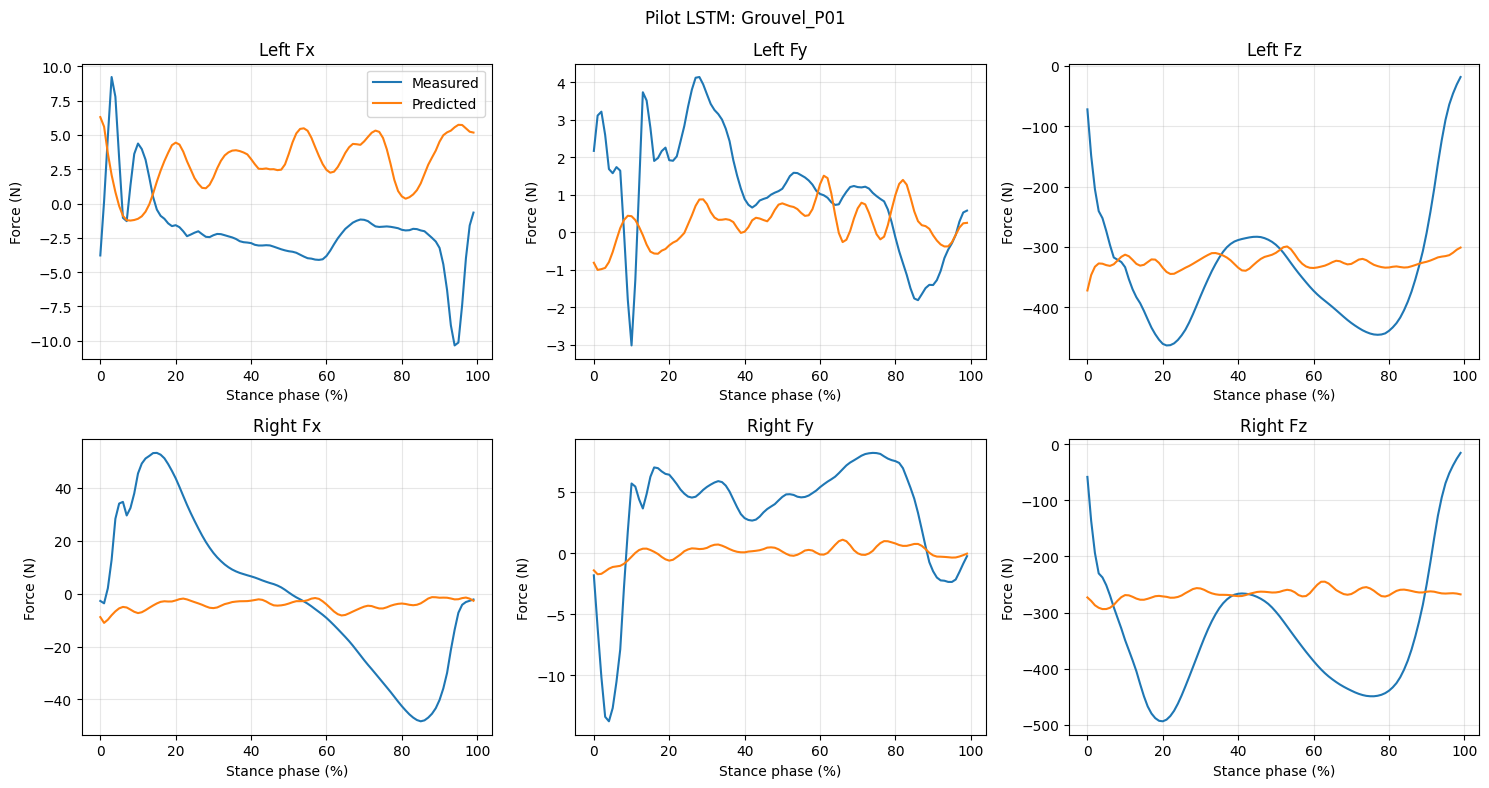

In [22]:
import matplotlib.pyplot as plt

channels = [
    "Left Fx", "Left Fy", "Left Fz",
    "Right Fx", "Right Fy", "Right Fz"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, ax in enumerate(axes.flat):
    ax.plot(Y_test[:, :, i].mean(0), label="Measured")
    ax.plot(Y_pred[:, :, i].mean(0), label="Predicted")

    ax.set(
        title=channels[i],
        xlabel="Stance phase (%)",
        ylabel="Force (N)"
    )
    ax.grid(alpha=0.3)

axes[0, 0].legend()
fig.suptitle(f"Pilot LSTM: {groups[test_index][0]}")

plt.tight_layout()
plt.show()

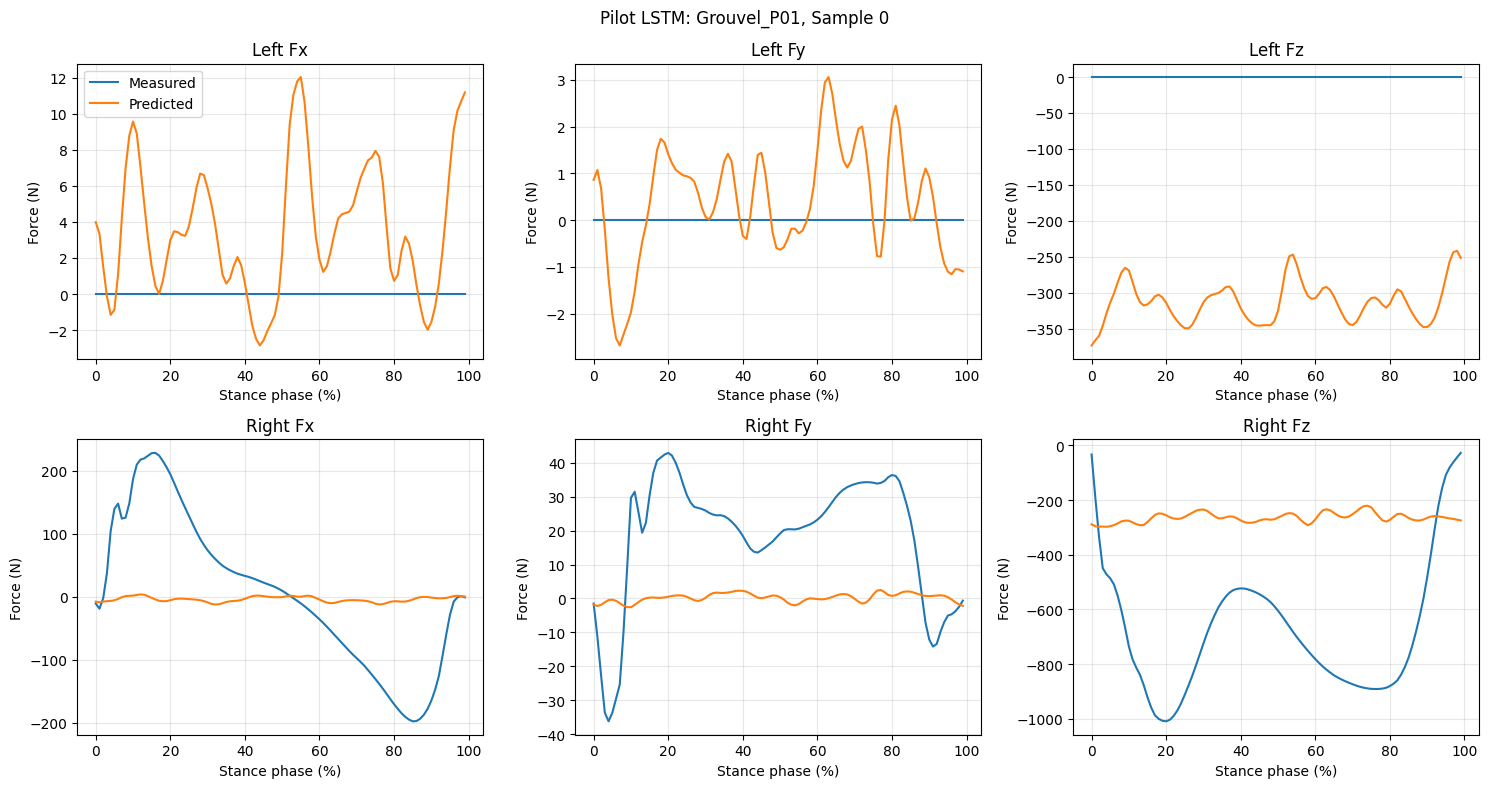

In [23]:
sample = 0

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, ax in enumerate(axes.flat):
    ax.plot(Y_test[sample, :, i], label="Measured")
    ax.plot(Y_pred[sample, :, i], label="Predicted")
    ax.set(
        title=channels[i],
        xlabel="Stance phase (%)",
        ylabel="Force (N)"
    )
    ax.grid(alpha=0.3)

axes[0, 0].legend()
fig.suptitle(f"Pilot LSTM: {groups[test_index][0]}, Sample {sample}")

plt.tight_layout()
plt.show()

### **5. Full LOSO Analysis**

## **5.1 Create the Side-Specific Datasets**

In [24]:
# Separate the GRF targets
Y_left = Y[:, :, :3]
Y_right = Y[:, :, 3:]

# Identify datasets
is_lavikainen = df["Dataset"].eq("Lavikainen").to_numpy()
is_grouvel = df["Dataset"].eq("Grouvel").to_numpy()

# Check which Grouvel targets contain measured forces
left_measured = np.any(np.abs(Y_left) > 0, axis=(1, 2))
right_measured = np.any(np.abs(Y_right) > 0, axis=(1, 2))

# Keep all Lavikainen samples and valid Grouvel samples
left_mask = is_lavikainen | (is_grouvel & left_measured)
right_mask = is_lavikainen | (is_grouvel & right_measured)

# Create the two datasets
X_left = X[left_mask]
Y_left = Y_left[left_mask]
groups_left = groups[left_mask]

X_right = X[right_mask]
Y_right = Y_right[right_mask]
groups_right = groups[right_mask]

print("Left model")
print("X:", X_left.shape)
print("Y:", Y_left.shape)
print("Participants:", len(np.unique(groups_left)))

print("\nRight model")
print("X:", X_right.shape)
print("Y:", Y_right.shape)
print("Participants:", len(np.unique(groups_right)))

Left model
X: (2858, 100, 6)
Y: (2858, 100, 3)
Participants: 58

Right model
X: (2849, 100, 6)
Y: (2849, 100, 3)
Participants: 58


## **5.2 Define the Left-GRF LOSO Functions**

## **5.2.1 Define the Left-GRF LSTM**

In [25]:
def build_left_lstm():
    model = Sequential([
        Input(shape=(100, 6)),
        LSTM(64, return_sequences=True),
        Dense(3)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

## **5.2.2 Define Early Stopping**

In [26]:
def get_early_stopping():
    return EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True
    )

## **5.2.3 Define the Evaluation Function**

In [27]:
def calculate_metrics(measured, predicted):
    rmse = np.sqrt(np.mean((measured - predicted) ** 2))
    rrmse = 100 * rmse / (measured.max() - measured.min())
    r = pearsonr(measured, predicted)[0]

    return rmse, rrmse, r

## **5.2.4 Set Up the Left LOSO Results**

In [28]:
left_channels = ["Left_Fx", "Left_Fy", "Left_Fz"]

left_results = []
left_predictions = []
left_histories = []

left_participants = np.unique(groups_left)

print("Number of left LOSO folds:", len(left_participants))

Number of left LOSO folds: 58


## **5.3 Run the Left-GRF LOSO Loop**

In [29]:
# from sklearn.model_selection import train_test_split

# for fold, test_pid in enumerate(left_participants, start=1):

#     # Separate test participant
#     test_mask = groups_left == test_pid
#     trainval_mask = ~test_mask

#     # Split the remaining participants into training and validation
#     remaining_pids = np.unique(groups_left[trainval_mask])

#     train_pids, val_pids = train_test_split(
#         remaining_pids,
#         test_size=0.2,
#         random_state=42
#     )

#     train_mask = np.isin(groups_left, train_pids)
#     val_mask = np.isin(groups_left, val_pids)

#     X_train, Y_train = X_left[train_mask], Y_left[train_mask]
#     X_val, Y_val = X_left[val_mask], Y_left[val_mask]
#     X_test, Y_test_left = X_left[test_mask], Y_left[test_mask]

#     # Fit scalers using training data only
#     x_scaler = StandardScaler()
#     y_scaler = StandardScaler()

#     X_train_scaled = x_scaler.fit_transform(
#         X_train.reshape(-1, 6)
#     ).reshape(X_train.shape)

#     X_val_scaled = x_scaler.transform(
#         X_val.reshape(-1, 6)
#     ).reshape(X_val.shape)

#     X_test_scaled = x_scaler.transform(
#         X_test.reshape(-1, 6)
#     ).reshape(X_test.shape)

#     Y_train_scaled = y_scaler.fit_transform(
#         Y_train.reshape(-1, 3)
#     ).reshape(Y_train.shape)

#     Y_val_scaled = y_scaler.transform(
#         Y_val.reshape(-1, 3)
#     ).reshape(Y_val.shape)

#     # Build and train a fresh model
#     model = build_left_lstm()

#     history = model.fit(
#         X_train_scaled,
#         Y_train_scaled,
#         validation_data=(X_val_scaled, Y_val_scaled),
#         epochs=150,
#         batch_size=32,
#         callbacks=[get_early_stopping()],
#         verbose=0
#     )

#     # Predict and return to original GRF units
#     Y_pred_scaled = model.predict(X_test_scaled, verbose=0)

#     Y_pred_left = y_scaler.inverse_transform(
#         Y_pred_scaled.reshape(-1, 3)
#     ).reshape(Y_pred_scaled.shape)

#     # Calculate metrics
#     for i, channel in enumerate(left_channels):
#         measured = Y_test_left[:, :, i].flatten()
#         predicted = Y_pred_left[:, :, i].flatten()

#         rmse, rrmse, r = calculate_metrics(measured, predicted)

#         left_results.append([
#             test_pid, channel, rmse, rrmse, r
#         ])

#     # Store predictions and training information
#     left_predictions.append({
#         "Participant": test_pid,
#         "Measured": Y_test_left,
#         "Predicted": Y_pred_left
#     })

#     left_histories.append({
#         "Participant": test_pid,
#         "Epochs": len(history.history["loss"]),
#         "Best_val_loss": min(history.history["val_loss"])
#     })

#     print(
#         f"Fold {fold}/58 completed: {test_pid} "
#         f"({len(history.history['loss'])} epochs)"
#     )

In [30]:
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reset stored results
left_results = []
left_predictions = []
left_histories = []

# Run left-GRF LOSO
for fold, test_pid in enumerate(left_participants, start=1):

    # Participant masks
    test_mask = groups_left == test_pid
    remaining_pids = np.unique(groups_left[~test_mask])

    # Participant-level training and validation split
    train_pids, val_pids = train_test_split(
        remaining_pids,
        test_size=0.2,
        random_state=42
    )

    train_mask = np.isin(groups_left, train_pids)
    val_mask = np.isin(groups_left, val_pids)

    X_train = X_left[train_mask]
    Y_train = Y_left[train_mask]

    X_val = X_left[val_mask]
    Y_val = Y_left[val_mask]

    X_test = X_left[test_mask]
    Y_test_left = Y_left[test_mask]

    # Fit scalers on training data
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(
        X_train.reshape(-1, 6)
    ).reshape(X_train.shape)

    X_val_scaled = x_scaler.transform(
        X_val.reshape(-1, 6)
    ).reshape(X_val.shape)

    X_test_scaled = x_scaler.transform(
        X_test.reshape(-1, 6)
    ).reshape(X_test.shape)

    Y_train_scaled = y_scaler.fit_transform(
        Y_train.reshape(-1, 3)
    ).reshape(Y_train.shape)

    Y_val_scaled = y_scaler.transform(
        Y_val.reshape(-1, 3)
    ).reshape(Y_val.shape)

    # Build and train a new model
    model = build_left_lstm()

    history = model.fit(
        X_train_scaled,
        Y_train_scaled,
        validation_data=(X_val_scaled, Y_val_scaled),
        epochs=150,
        batch_size=32,
        callbacks=[get_early_stopping()],
        verbose=0
    )

    # Predict without model.predict()
    Y_pred_scaled = model(
        X_test_scaled,
        training=False
    ).numpy()

    # Return predictions to the original GRF units
    Y_pred_left = y_scaler.inverse_transform(
        Y_pred_scaled.reshape(-1, 3)
    ).reshape(Y_pred_scaled.shape)

    # Calculate metrics
    for i, channel in enumerate(left_channels):

        measured = Y_test_left[:, :, i].flatten()
        predicted = Y_pred_left[:, :, i].flatten()

        rmse, rrmse, r = calculate_metrics(
            measured,
            predicted
        )

        left_results.append([
            test_pid,
            channel,
            rmse,
            rrmse,
            r
        ])

    # Store predictions
    left_predictions.append({
        "Participant": test_pid,
        "Measured": Y_test_left,
        "Predicted": Y_pred_left
    })

    # Store training information
    left_histories.append({
        "Participant": test_pid,
        "Epochs": len(history.history["loss"]),
        "Best_val_loss": min(history.history["val_loss"])
    })

    print(
        f"Fold {fold}/{len(left_participants)} completed: "
        f"{test_pid} ({len(history.history['loss'])} epochs)"
    )

    # Release the completed model from memory
    del model
    tf.keras.backend.clear_session()

Fold 1/58 completed: Grouvel_P01 (37 epochs)
Fold 2/58 completed: Grouvel_P02 (33 epochs)
Fold 3/58 completed: Grouvel_P03 (33 epochs)
Fold 4/58 completed: Grouvel_P04 (50 epochs)
Fold 5/58 completed: Grouvel_P05 (34 epochs)
Fold 6/58 completed: Grouvel_P06 (36 epochs)
Fold 7/58 completed: Grouvel_P07 (34 epochs)
Fold 8/58 completed: Grouvel_P08 (40 epochs)
Fold 9/58 completed: Grouvel_P09 (42 epochs)
Fold 10/58 completed: Grouvel_P10 (36 epochs)
Fold 11/58 completed: Lavikainen_1 (43 epochs)
Fold 12/58 completed: Lavikainen_10 (30 epochs)
Fold 13/58 completed: Lavikainen_12 (32 epochs)
Fold 14/58 completed: Lavikainen_13 (33 epochs)
Fold 15/58 completed: Lavikainen_15 (34 epochs)
Fold 16/58 completed: Lavikainen_16 (28 epochs)
Fold 17/58 completed: Lavikainen_17 (29 epochs)
Fold 18/58 completed: Lavikainen_18 (29 epochs)
Fold 19/58 completed: Lavikainen_19 (49 epochs)
Fold 20/58 completed: Lavikainen_2 (29 epochs)
Fold 21/58 completed: Lavikainen_20 (29 epochs)
Fold 22/58 completed: L

## **5.4 Convert the Left LOSO Results**

In [31]:
left_results_df = pd.DataFrame(
    left_results,
    columns=[
        "Participant",
        "Channel",
        "RMSE",
        "rRMSE_percent",
        "Pearson_r"
    ]
)

left_histories_df = pd.DataFrame(left_histories)

display(left_results_df.head())

,Participant,Channel,RMSE,rRMSE_percent,Pearson_r
0,Grouvel_P01,Left_Fx,111.363291,26.385822,0.082994
1,Grouvel_P01,Left_Fy,32.769905,20.880905,0.185889
2,Grouvel_P01,Left_Fz,247.691061,26.797696,0.296247
3,Grouvel_P02,Left_Fx,42.097827,23.242923,0.061824
4,Grouvel_P02,Left_Fy,12.317482,24.519324,0.118959


## **5.5 Verify the Results**

In [32]:
print("Metric rows:", len(left_results_df))
print("Participants:", left_results_df["Participant"].nunique())
print("Channels:", left_results_df["Channel"].unique())
print("History rows:", len(left_histories_df))

print("\nMissing values:")
print(left_results_df.isna().sum())

Metric rows: 174
Participants: 58
Channels: ['Left_Fx' 'Left_Fy' 'Left_Fz']
History rows: 58

Missing values:
Participant      0
Channel          0
RMSE             0
rRMSE_percent    0
Pearson_r        0
dtype: int64


In [33]:
left_summary = (
    left_results_df
    .groupby("Channel")[["RMSE", "rRMSE_percent", "Pearson_r"]]
    .agg(["mean", "std"])
    .round(3)
)

display(left_summary)

RMSE         rRMSE_percent        Pearson_r       
            mean     std          mean    std      mean    std
Channel                                                       
Left_Fx   79.805  19.797        22.440  1.838     0.003  0.078
Left_Fy   24.652   8.192        21.023  3.138     0.019  0.083
Left_Fz  182.010  94.965        19.881  9.304     0.736  0.356

In [34]:
left_results_df["Dataset"] = (
    left_results_df["Participant"]
    .str.split("_")
    .str[0]
)

left_dataset_summary = (
    left_results_df
    .groupby(["Dataset", "Channel"])[
        ["RMSE", "rRMSE_percent", "Pearson_r"]
    ]
    .agg(["mean", "std"])
    .round(3)
)

display(left_dataset_summary)

RMSE         rRMSE_percent        Pearson_r       
                       mean     std          mean    std      mean    std
Dataset    Channel                                                       
Grouvel    Left_Fx   85.897  28.779        24.091  2.234    -0.048  0.091
           Left_Fy   22.939   8.486        22.594  4.396     0.067  0.098
           Left_Fz  274.577  75.759        32.248  5.412     0.068  0.183
Lavikainen Left_Fx   78.536  17.526        22.096  1.562     0.013  0.071
           Left_Fy   25.009   8.175        20.696  2.758     0.009  0.077
           Left_Fz  162.725  87.380        17.304  7.749     0.875  0.180

In [35]:
left_participant_metrics = (
    left_results_df[
        ["Participant", "Dataset", "Channel",
         "RMSE", "rRMSE_percent", "Pearson_r"]
    ]
    .sort_values(["Dataset", "Participant", "Channel"])
    .reset_index(drop=True)
    .round(3)
)

display(left_participant_metrics)

,Participant,Dataset,Channel,RMSE,rRMSE_percent,Pearson_r
0,Grouvel_P01,Grouvel,Left_Fx,111.363,26.386,0.083
1,Grouvel_P01,Grouvel,Left_Fy,32.770,20.881,0.186
2,Grouvel_P01,Grouvel,Left_Fz,247.691,26.798,0.296
3,Grouvel_P02,Grouvel,Left_Fx,42.098,23.243,0.062
4,Grouvel_P02,Grouvel,Left_Fy,12.317,24.519,0.119
...,...,...,...,...,...,...
169,Lavikainen_8,Lavikainen,Left_Fy,32.225,24.265,0.011
170,Lavikainen_8,Lavikainen,Left_Fz,108.213,12.559,0.952
171,Lavikainen_9,Lavikainen,Left_Fx,73.385,23.409,0.037
172,Lavikainen_9,Lavikainen,Left_Fy,19.922,22.650,0.080


In [36]:
# Create the participant table
left_participant_table = left_participant_metrics.pivot(
    index=["Dataset", "Participant"],
    columns="Channel",
    values=["RMSE", "rRMSE_percent", "Pearson_r"]
).round(3)

# Save as TXT files
left_participant_metrics.to_csv(
    "/kaggle/working/left_grf_standard_lstm_participant_metrics.txt",
    sep="\t",
    index=False
)

left_participant_table.to_csv(
    "/kaggle/working/left_grf_standard_lstm_participant_table.txt",
    sep="\t"
)

print("TXT results saved to the Kaggle output directory.")

TXT results saved to the Kaggle output directory.
